In [1]:
import numpy as np
import h5py
from tenpy.tools.hdf5_io import Hdf5Loader
import pandas as pd
import glob
import signac


from itertools import product
from datetime import datetime


from plotnine import *
project = signac.get_project("../../../",)
project.detect_schema()

ProjectSchema(<len=77>)

In [2]:

from matplotlib import rcParams

# This enables the LaTeX renderer
rcParams['text.usetex'] = True

# This ensures the font matches the standard LaTeX Computer Modern look
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern Roman']

# plotting settings:
theme_prl_latex = (
    theme_bw() + 
    theme(
        # Standardize text
        text=element_text(size=10, family='serif'),
        axis_title_x=element_text(size=10, family='serif'),
        axis_title_y=element_text(size=10, family='serif'),
        
        # Facet/Strip adjustments
        strip_background=element_blank(),
        strip_text_x=element_text(size=10, margin={'t': 15, 'b': 5, 'l':5, 'r':15}),
        strip_text_y=element_text(size=10, margin={'t': 15, 'b': 5, 'l':5, 'r':15}),

        
        # Panel and Borders
        panel_grid_major=element_blank(), # PRL figures rarely use grids
        panel_grid_minor=element_blank(),
        panel_border=element_rect(colour="black", fill=None, size=0.8),
        
        # Legend
        legend_title=element_text(size=9),
        legend_key=element_blank(),
        legend_position='top'
    )
)

In [3]:
current_jobs = {'model_params.Nf':2, 
                'model_params.a':0.3, 
                'model_params.m':{"$in":[[0.,0.],[0.3335,3]]}, 
                'model_params.L':32,
                'model_params.Nr':4,
                'model_class':'MassiveSchwingerModelQubitEncoding',
                'algorithm_params.trunc_params.chi_max':[256,512,1024,2048], 
                }

df_params = project.find_jobs(current_jobs).to_dataframe(flatten=True)
df_params['a'] = df_params['sp.model_params.a']
df_params['g'] = df_params['sp.model_params.g']
df_params['Nf_num'] = df_params['sp.model_params.Nf']
df_params['Nf'] = pd.Categorical(df_params['sp.model_params.Nf'], categories=[3,2,1], ordered=True)
df_params['Nr_num'] = df_params['sp.model_params.Nr']
df_params['bc'] = df_params['sp.model_params.bc_x']

#df_params['$\theta$'] = df_params['sp.model_params.theta'].apply(lambda x: "$\pi$" if np.abs(x-np.pi)<1e-10 else "0")
df_params[r'\theta'] = df_params['sp.model_params.theta'].apply(lambda x: r"\pi" if np.abs(x-np.pi)<1e-10 else "0")
df_params['m'] = df_params['sp.model_params.m'].apply(lambda x: '(' + ','.join([str(i) for i in x]) + ')')
df_params['diag_method'] = df_params['sp.algorithm_params.diag_method'].apply(lambda x: x[0])
#df_params['charge_mod'] = df_params['sp.model_params.charge_mod'].apply(lambda x: 0 if x is None else x[0])
df_params['L'] =df_params['sp.model_params.L']
df_params

,sp.simulation_class,sp.sequential.recursive_keys,sp.output_filename,sp.save_psi,sp.model_class,sp.model_params.model_name,sp.model_params.Nf,sp.model_params.Nr,sp.model_params.m,sp.model_params.g,...,a,g,Nf_num,Nf,Nr_num,bc,\theta,m,diag_method,L
6de3e2c4996e0fd1dd7e1309ac0ac1d9,GroundStateSearch,"(algorithm_params.trunc_params.chi_max,)",results_simulation.h5,False,MassiveSchwingerModelQubitEncoding,MassiveSchwingerModelVR,2,4,"(0.0, 0.0)",1.0,...,0.3,1.0,2,2,4,open,\pi,"(0.0,0.0)",d,32
d48d6bc46f7f52cfa53fe1cf59276f27,GroundStateSearch,"(algorithm_params.trunc_params.chi_max,)",results_simulation.h5,False,MassiveSchwingerModelQubitEncoding,MassiveSchwingerModelVR,2,4,"(0.0, 0.0)",1.0,...,0.3,1.0,2,2,4,periodic,\pi,"(0.0,0.0)",d,32
aa9e2a47a58d84a146d55f1e4483d8e2,GroundStateSearch,"(algorithm_params.trunc_params.chi_max,)",results_simulation.h5,False,MassiveSchwingerModelQubitEncoding,MassiveSchwingerModelVR,2,4,"(0.3335, 3.0)",1.0,...,0.3,1.0,2,2,4,open,\pi,"(0.3335,3.0)",d,32
97959a4cdb669dc4b6a1a1b5637377ee,GroundStateSearch,"(algorithm_params.trunc_params.chi_max,)",results_simulation.h5,False,MassiveSchwingerModelQubitEncoding,MassiveSchwingerModelVR,2,4,"(0.3335, 3.0)",1.0,...,0.3,1.0,2,2,4,periodic,\pi,"(0.3335,3.0)",d,32


In [4]:
df = {'entropy': [], 'energy':[], 'r':[]}
df_fitted = {'entropy':[], 'r':[]}
df_predicted = {'entropy':[], 'r':[]}
df_labels = {'label':[], 'entropy':[], 'r':[]}
indices = []
for job in project.find_jobs(current_jobs):
    for res_file in glob.glob(job.fn('results_simulation.h5')):
        with h5py.File(job.fn(res_file), 'r') as f:
            EE = Hdf5Loader(f['measurements']['entropy']).load()
            E = Hdf5Loader(f['energy']).load()
            GS = Hdf5Loader(f['measurements']['Gausses_law']).load()
            df['entropy'].append(EE[-1, :])
            df['energy'].append(E)
            print(job.id)
            indices.append(job.id)
    for res_file in glob.glob(job.fn('results_central_charge_per_unit.h5')):
        with h5py.File(job.fn(res_file), 'r') as f:
            EE_fit = Hdf5Loader(f['fitted_entropies']).load()
            r_fit = Hdf5Loader(f['fitted_cuts']).load()
            EE_pred = Hdf5Loader(f['model_preditions']).load()
            r_all  = Hdf5Loader(f['all_cuts']).load()
            params = Hdf5Loader(f['params']).load()
            cov = Hdf5Loader(f['cov']).load()
            df['r'].append(r_all)
            df_fitted['entropy'].append(EE_fit)
            df_fitted['r'].append(r_fit)
            df_predicted['entropy'].append(EE_pred)
            df_predicted['r'].append(r_all)
            df_labels['entropy'].append(0.5*(np.max(EE)-np.min(EE))+ np.min(EE))
            df_labels['r'].append(0.5*(np.max(r_all)-np.min(r_all)) + np.min(r_all))
            df_labels['label'].append(f"$c={params[0]:.3f} \\pm {np.sqrt(cov[0,0]):.3f}$ \n $S_0 = {params[1]:.3f} \\pm {np.sqrt(cov[1,1]):.3f}$")

df= pd.DataFrame(df, index=indices)
df_labels= pd.DataFrame(df_labels, index=indices)
df_fitted= pd.DataFrame(df_fitted, index=indices)
df_predicted= pd.DataFrame(df_predicted, index=indices)

#df = pd.merge(df_params, df, left_index=True, right_index=True)

6de3e2c4996e0fd1dd7e1309ac0ac1d9
d48d6bc46f7f52cfa53fe1cf59276f27
aa9e2a47a58d84a146d55f1e4483d8e2
97959a4cdb669dc4b6a1a1b5637377ee


In [5]:
rows = []

# Loop through each row manually
for idx, row in df.iterrows():
    entropy = row['entropy']
    rs = row['r']
    for i, val in zip(rs, entropy):
        rows.append({'index': idx, 'r': i, 'entropy': val})

# Create the long-format DataFrame
df = pd.DataFrame(rows)
df = df.merge(df_params, left_on='index', right_index=True)


rows = []

# Loop through each row manually
for idx, row in df_fitted.iterrows():
    entropy = row['entropy']
    rs = row['r']
    for i, val in zip(rs, entropy):
        rows.append({'index': idx, 'r': i, 'entropy': val})

df_fitted = pd.DataFrame(rows)
df_fitted = df_fitted.merge(df_params, left_on='index', right_index=True)

rows = []

# Loop through each row manually
for idx, row in df_predicted.iterrows():
    entropy = row['entropy']
    rs = row['r']
    for i, val in zip(rs, entropy):
        rows.append({'index': idx, 'r': i, 'entropy': val})

# Create the long-format DataFrame

df_predicted = pd.DataFrame(rows)
df_predicted = df_predicted.merge(df_params, left_on='index', right_index=True)

df_labels = df_labels.merge(df_params, left_index=True, right_index=True)
df_labels['index'] = df_labels.index

/local/dmr369/micromamba/envs/Rogerson_et_al_Virtual_Rishon_Formulation/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 4.666666666666667 x 4.2 in image.
/local/dmr369/micromamba/envs/Rogerson_et_al_Virtual_Rishon_Formulation/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../../../plots/2026-03-04_plot_boundary_effects.pdf
/local/dmr369/micromamba/envs/Rogerson_et_al_Virtual_Rishon_Formulation/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'size' aesthetic. Make sure you have mapped a variable to it
/local/dmr369/micromamba/envs/Rogerson_et_al_Virtual_Rishon_Formulation/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'size' aesthetic. Make sure you have mapped a variable to it


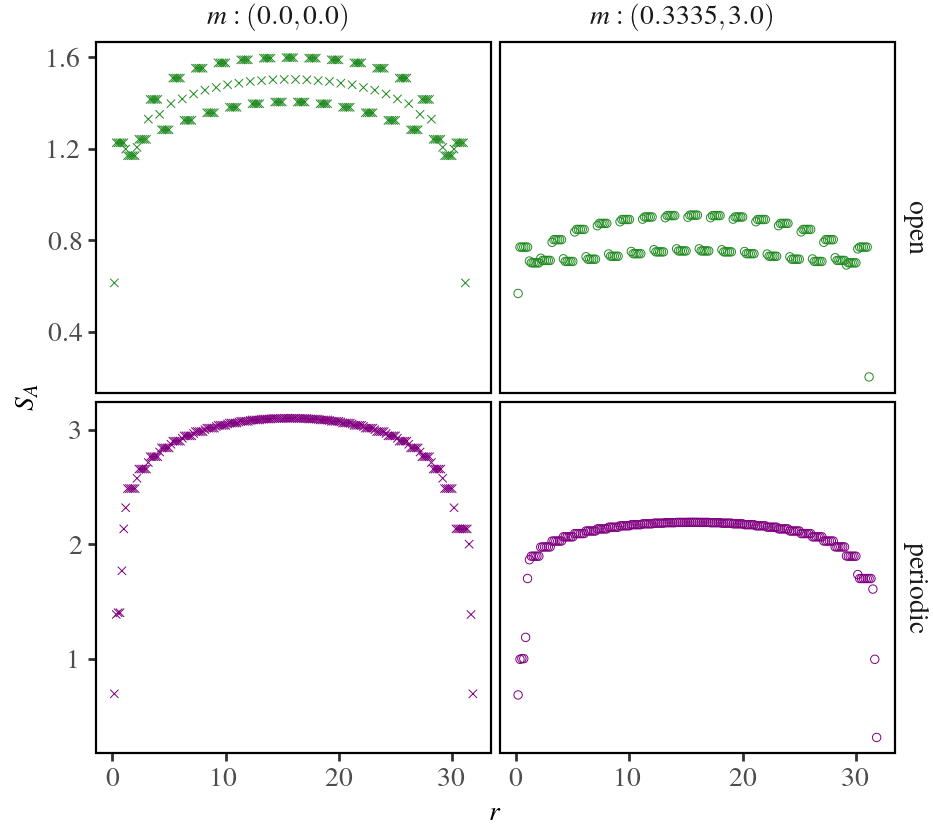

In [7]:
df_i = df
df_f = df_fitted
df_p = df_predicted

df_l = df_labels

def col_labeller(labels):
    theta = "\pi" if np.abs(float(labels) - np.pi)<1e-10 else  "0"
    return f"$\\theta = {theta}$"
def label_func(key, val):
    if key=='Nf':
        key = "N_f"
    return f"${key}:{val}$"
p = (ggplot(df_i, aes(x='r', y='entropy', color='factor(bc)', shape='m' ))

+ geom_point(fill='None', stroke=0.2, size=1.5,show_legend=False)

+facet_grid(r'bc ~ m ', labeller=labeller(
    multi_line=False, **{key:(lambda x, key=key: label_func(key, x)) for key in ['N', 'g', 'a', r'\theta', 'Nf', 'm', 'L']}),
    scales='free_y')
+ scale_shape_manual(values=['x', 'o', '2', '+'])  # Custom shape for each cyl
+ scale_size_manual(values=[4, 4, 4, 2])  # Custom shape for each cyl
+ scale_color_manual(values=[ 'forestgreen', 'purple'])

+ theme_prl_latex
+ theme(
    figure_size=(7/3*2, 7/3*1.8),  # Width x height in inches
    legend_position=None,  # X and Y inside the plot area
    plot_margin=(0.015),
)

+labs(#title='Groundstate Energy $E_0$ vs $m_1=m_2$',
         y='$S_{A}$',
         x='$r$',
         color='',
         shape=''
         )
)
#+ theme_minimal()
ggsave(p, "../../../plots/"+datetime.today().strftime('%Y-%m-%d') + "_plot_boundary_effects.pdf", bbox_inches='tight')
p